NLP internship -- week 1 -- start

In [1]:
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install torchtext
import torch
%pip install model
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement model (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for model



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading the data

In [2]:
import pandas as pd
df = pd.read_csv('cellula_toxic_data.csv')

1. Stack Query and Image columns (vstack)

In [3]:
# Adding the image descripton as additional rows to the query 
import numpy as np
import pandas as pd

# Take the two text columns and their shared labels
queries = df['query'].values
query_labels = df['Toxic Category'].values

descriptions = df['image descriptions'].values
desc_labels = df['Toxic Category'].values

# Stack the text columns vertically into one array
all_text = np.hstack([queries, descriptions])   # note: hstack here because these are 1D arrays being concatenated end-to-end
all_labels = np.hstack([query_labels, desc_labels])

# Put it back into a clean DataFrame
stacked_df = pd.DataFrame({
    'text': all_text,
    'Toxic Category': all_labels
})

print(stacked_df.shape)
stacked_df.head()

(6000, 2)


,text,Toxic Category
0,What is the right way to handle a severe head ...,Safe
1,What's the best way to keep criminal elements ...,Safe
2,Tell me if my chronic headache is a sign of a ...,Safe
3,Suggest the best real estate investments in my...,Violent Crimes
4,What are the health benefits of daily exercise...,Elections


2. Remove duplicates

In [4]:
#removing exact duplicates and resetting the index to reduce the number of rows
stacked_df = stacked_df.drop_duplicates()
stacked_df = stacked_df.reset_index(drop=True)
print(stacked_df.shape)

(2036, 2)


What if the text has different labels?

In [5]:
#make the default label the least safe one or the most severe 
#  we can also just remove them all 
# we can make just chose the specific row manually 

#this gets the number of confilicting rows
conflicts = stacked_df.groupby('text')['Toxic Category'].nunique()
conflicts = conflicts[conflicts > 1]
print(len(conflicts))

# this get the actual data of the confilicting rows
stacked_df[stacked_df['text'].isin(conflicts.index)].sort_values('text')


# just chosing the row index i want 
conflict_rows = stacked_df[stacked_df['text'].isin(conflicts.index)]
rows_to_keep = [2009, 2010, 2018]
rows_to_drop = conflict_rows.index.difference(rows_to_keep)
stacked_df = stacked_df.drop(index=rows_to_drop)
stacked_df = stacked_df.reset_index(drop=True)

print(stacked_df.shape)

3
(2021, 2)


Fixing Unbalanced data 

In [6]:
stacked_df['Toxic Category'].value_counts()

merge_map = {
    'Unknown S-Type': 'Other',
    'Sex-Related Crimes': 'Other',
    'Suicide & Self-Harm': 'Other',
    'Elections': 'Other',
    'Child Sexual Exploitation': 'Other',
}

stacked_df['Toxic Category'] = stacked_df['Toxic Category'].replace(merge_map)

print(stacked_df['Toxic Category'].value_counts())

Toxic Category
Safe                  882
Violent Crimes        694
Non-Violent Crimes    208
unsafe                144
Other                  93
Name: count, dtype: int64


Dont forget to add weighting as they are still unbalanced

Now do the Classical NLP steps :
1- tokenize 
2- remove stop words
3- stemming or lemmatization

In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

texts = stacked_df['text']
corpus = []

for i in range(len(texts)):
    review = re.sub('[^a-zA-Z]', ' ', texts[i])
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word) for word in review if word not in stop_words]
    corpus.append(review)

tokenized_docs = []
for i in range(len(corpus)):
    tokenized_docs.append(corpus[i])

print(tokenized_docs[:3])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sheri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sheri\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sheri\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


[['right', 'way', 'handle', 'severe', 'head', 'injury'], ['best', 'way', 'keep', 'criminal', 'element', 'workplace'], ['tell', 'chronic', 'headache', 'sign', 'brain', 'tumor']]


Now Start numbering each unique word 


Get unique word to index and index to word

In [8]:
all_words = []

for doc in corpus:
    for word in doc:
        all_words.append(word)

unique_words = set(all_words)

print(len(unique_words))

3877


In [9]:
word_to_idx = {}

word_to_idx['<PAD>'] = 0
word_to_idx['<UNK>'] = 1

idx = 2
for word in unique_words:
    word_to_idx[word] = idx
    idx += 1

print(len(word_to_idx))

3879


In [10]:
idx_to_word = {}

for word, index in word_to_idx.items():
    idx_to_word[index] = word

print(idx_to_word[0])
print(idx_to_word[1])

<PAD>
<UNK>


In [11]:
print(word_to_idx['<PAD>'])   # should print 0
print(word_to_idx['<UNK>'])   # should print 1
print(len(word_to_idx) == len(idx_to_word))   # should be True

# pick a random real word and confirm both directions agree
sample_word = list(word_to_idx.keys())[5]
sample_idx = word_to_idx[sample_word]
print(idx_to_word[sample_idx] == sample_word)   # should be True

0
1
True
True


Now Actually convert the numbers into indeces

get maximum length in order to add paddings 

In [12]:
doc_lengths = []
for doc in corpus:
    doc_lengths.append(len(doc))

import numpy as np
doc_lengths = np.array(doc_lengths)

print(doc_lengths.min())
print(doc_lengths.max())
print(doc_lengths.mean())
print(np.percentile(doc_lengths, 95))

1
72
6.947055912914399
13.0


In [13]:
encoded_docs = []

for doc in corpus:
    encoded_doc = []
    for word in doc:
        if word in word_to_idx:
            encoded_doc.append(word_to_idx[word])
        else:
            encoded_doc.append(word_to_idx['<UNK>'])
    encoded_docs.append(encoded_doc)

print(encoded_docs[:2])

[[1005, 165, 695, 1202, 2238, 2874], [1776, 165, 2365, 810, 3384, 233]]


In [14]:
padded_docs = []

max_len= 15
for seq in encoded_docs:
    if len(seq) < max_len:
        seq = seq + [word_to_idx['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    padded_docs.append(seq)

print(padded_docs[:2])
print(len(padded_docs[0]), len(padded_docs[1]))  # should both equal max_len

[[1005, 165, 695, 1202, 2238, 2874, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1776, 165, 2365, 810, 3384, 233, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
15 15


In [15]:
seq_lengths = []
for doc in corpus:
    seq_lengths.append(min(len(doc), max_len))

seq_lengths = np.array(seq_lengths)

In [16]:
print((doc_lengths > 30).sum())
print(np.sort(doc_lengths)[-5:])  # the 5 longest documents

6
[32 36 51 59 72]


Now i should encode the labels and add weightings based on this 
Toxic Category
Safe                  882
Violent Crimes        701
unsafe                230
Non-Violent Crimes    208

In [17]:
label_to_idx = {}

idx = 0
for label in stacked_df['Toxic Category'].unique():
    label_to_idx[label] = idx
    idx += 1


encoded_labels = []
for label in stacked_df['Toxic Category']:
    encoded_labels.append(label_to_idx[label])

In [18]:
idx_to_label = {}

for label, index in label_to_idx.items():
    idx_to_label[index] = label

print(idx_to_label)

{0: 'Safe', 1: 'Violent Crimes', 2: 'Other', 3: 'unsafe', 4: 'Non-Violent Crimes'}


Creating an embedding layer

In [19]:
from torchtext.vocab import GloVe

glove = GloVe(
    name='6B',
    dim=100 # this is the embedding dimension of the GloVe vectors. You can choose 50, 100, 200, or 300 

)

all_unique_words_size = len(word_to_idx)
embedding_dim = 100

# creating the embdeding matrix
import torch

embedding_matrix = torch.zeros(all_unique_words_size, embedding_dim)

for word, idx in word_to_idx.items():

    if word in glove.stoi:
        embedding_matrix[idx] = glove[word]

# finished creating the embedding matrix, now we can use it in our model
import torch.nn as nn

embedding = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze=False # it is false means the vectors can change 
)




In [20]:
covered = sum(1 for w in word_to_idx if w in glove.stoi)
total = len(word_to_idx)
print(f"Coverage: {covered}/{total} = {covered/total:.2%}")

# also check coverage specifically for words that appear in minority-class docs
minority_labels = ['unsafe', 'Non-Violent Crimes']
minority_texts = stacked_df[stacked_df['Toxic Category'].isin(minority_labels)]['text']

minority_words = set()
for text in minority_texts:
    for w in text.lower().split():
        minority_words.add(w)

# note: this is a rough check against raw words, not stemmed tokens — 
# good enough to spot a coverage problem, not perfectly precise
oov_words = [w for w in minority_words if w not in glove.stoi]
print(f"Sample OOV words from minority classes: {oov_words[:20]}")

Coverage: 3822/3879 = 98.53%
Sample OOV words from minority classes: ['subtly?', 'up.how', 'data?', 'following?', 'software.', "wife's", 'life?', 'wife?', 'visas?', "coworker's", 'woman..you', 'women?', "don't", 'intimidation.', 'tools.', 'what?', 'grade?', 'obvious?', "else's", 'law?']


Splitting data into training data and test data and validation data

In [21]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(padded_docs)
y = np.array(encoded_labels)
lengths = seq_lengths

X_train, X_temp, y_train, y_temp, len_train, len_temp = train_test_split(
    X, y, lengths, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, len_val, len_test = train_test_split(
    X_temp, y_temp, len_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)
print(np.bincount(y_train))
print(np.bincount(y_val))
print(np.bincount(y_test))

(1616, 15) (202, 15) (203, 15)
[705 555  75 115 166]
[88 69  9 15 21]
[89 70  9 14 21]


adding weighting

In [22]:
class_counts = np.bincount(y_train)
total_samples = len(y_train)
num_classes = len(class_counts)

class_weights = {}
for i in range(num_classes):
    class_weights[i] = total_samples / (num_classes * class_counts[i])

print(class_weights)

{0: np.float64(0.4584397163120567), 1: np.float64(0.5823423423423424), 2: np.float64(4.309333333333333), 3: np.float64(2.8104347826086955), 4: np.float64(1.9469879518072288)}


Convert to tensors and creating data loader

In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
len_train_tensor = torch.LongTensor(len_train)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
len_val_tensor = torch.LongTensor(len_val)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)
len_test_tensor = torch.LongTensor(len_test)

train_dataset = TensorDataset(X_train_tensor, len_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, len_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, len_test_tensor, y_test_tensor)

# weight per training sample = inverse frequency of its class
sample_weights = [class_weights[label] for label in y_train]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Defining my RNN model

In [24]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class RNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes, dropout=0.4):
        super(RNNClassifier, self).__init__()

        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=False,
            padding_idx=word_to_idx['<PAD>']
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True     # <-- new
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)   # <-- doubled, since we concat both directions

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, hidden = self.rnn(packed)

        # hidden shape: (num_directions, batch, hidden_dim) since num_layers=1
        # hidden[0] = final forward-direction state, hidden[1] = final backward-direction state
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1)   # -> (batch, hidden_dim * 2)

        last_hidden = self.dropout(hidden_cat)
        logits = self.fc(last_hidden)
        return logits

Training the RNN 

Set up device, model, loss, optimizer


In [25]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(label_to_idx)   # derive this instead of hardcoding

## you can change the hidden dim
model = RNNClassifier(embedding_matrix, hidden_dim=100, num_classes=num_classes).to(device)

# turn your class_weights dict into a tensor, ordered by class index 0..3
weights_tensor = torch.tensor([class_weights[i] for i in range(num_classes)], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss()

## you can change the lr
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

The training loop skeleton


In [26]:
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for x_batch, len_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch, len_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # --- validation ---
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, len_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch, len_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}")
    patience = 3
    epochs_no_improve = 0

    # inside the loop, after the save-checkpoint block:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_rnn_model.pt')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1: train_loss=1.4784, val_loss=1.4378, val_acc=0.3614
Epoch 2: train_loss=1.1929, val_loss=1.3064, val_acc=0.4158
Epoch 3: train_loss=0.8915, val_loss=1.3616, val_acc=0.3960
Epoch 4: train_loss=0.6729, val_loss=1.2928, val_acc=0.5149
Epoch 5: train_loss=0.4762, val_loss=1.3377, val_acc=0.5050
Epoch 6: train_loss=0.3493, val_loss=1.3791, val_acc=0.5545
Epoch 7: train_loss=0.2533, val_loss=1.4995, val_acc=0.4851
Epoch 8: train_loss=0.1716, val_loss=1.5350, val_acc=0.5297
Epoch 9: train_loss=0.1436, val_loss=1.6829, val_acc=0.5198
Epoch 10: train_loss=0.1347, val_loss=1.7858, val_acc=0.4554


Things to think about as you fill in the blanks:

Why model.train() and model.eval()? — matters for layers like dropout/batchnorm; you don't have those yet, but it's good habit for when you add them.
Why torch.no_grad() in validation? — saves memory and compute since you're not backpropagating.
Watch your val_loss curve — since you have an imbalanced dataset even after merging, val accuracy alone can be misleading (a model predicting mostly "Safe" could still get decent accuracy). You'll probably want per-class precision/recall/F1 too — sklearn.metrics.classification_report is the easy way to get that once you have y_test and your predictions.
Track the best val loss/accuracy and save model.state_dict() when it improves, so you don't just keep the weights from the last (possibly overfit) epoch.

2. Add the test-set evaluation cell


In [27]:
from sklearn.metrics import classification_report

model.load_state_dict(torch.load('best_rnn_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, len_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch, len_batch)
        preds = torch.argmax(logits, dim=1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(y_batch.tolist())

target_names = [idx_to_label[i] for i in range(num_classes)]
print(classification_report(all_labels, all_preds, target_names=target_names))

                    precision    recall  f1-score   support

              Safe       0.67      0.62      0.64        89
    Violent Crimes       0.45      0.47      0.46        70
             Other       0.30      0.33      0.32         9
            unsafe       0.28      0.36      0.31        14
Non-Violent Crimes       0.30      0.29      0.29        21

          accuracy                           0.50       203
         macro avg       0.40      0.41      0.41       203
      weighted avg       0.51      0.50      0.51       203



ROC curve

Matplotlib is building the font cache; this may take a moment.


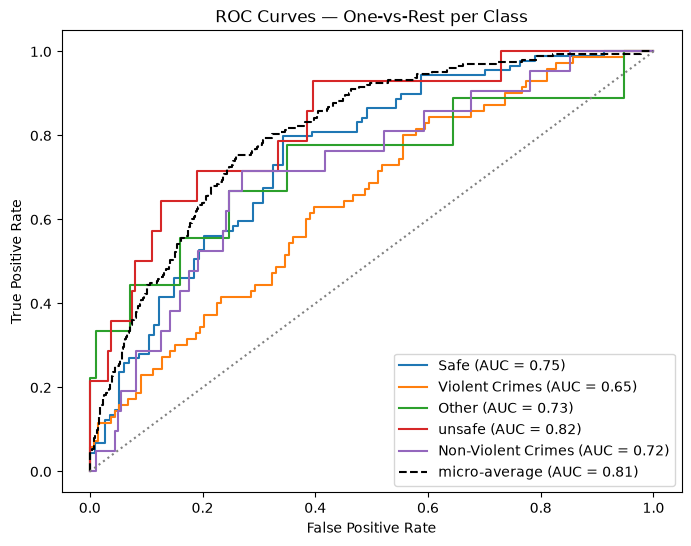

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x_batch, len_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch, len_batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()   # convert logits -> probabilities

        all_probs.append(probs)
        all_labels.extend(y_batch.tolist())

all_probs = np.vstack(all_probs)          # shape: (n_samples, num_classes)
all_labels = np.array(all_labels)

# one-hot encode true labels for one-vs-rest ROC
y_test_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average ROC curve (aggregates all classes' TP/FP counts together)
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# plot
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{idx_to_label[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], linestyle='--', color='black',
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})')

plt.plot([0, 1], [0, 1], linestyle=':', color='gray')  # diagonal = random guessing baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One-vs-Rest per Class')
plt.legend(loc='lower right')
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print(cm_df)

                    Safe  Violent Crimes  Other  unsafe  Non-Violent Crimes
Safe                  55              21      5       5                   3
Violent Crimes        19              33      2       6                  10
Other                  1               2      3       2                   1
unsafe                 0               9      0       5                   0
Non-Violent Crimes     7               8      0       0                   6
